In [1]:
import torch

def get_input_data(batch, node_features, with_hit_correction=True):
    if "hit" in node_features[0] and with_hit_correction:
        input_data = torch.stack(
            [batch[feature[4:]] for feature in node_features], dim=-1
        ).float()
    else:
        input_data = torch.stack(
            [batch[feature] for feature in node_features], dim=-1
        ).float()
    print("number of NaN: ", torch.sum(input_data != input_data).item())
    input_data[input_data != input_data] = 0  # Replace NaNs with 0s

    return input_data

In [147]:
event_id = 6800
device = "cpu"
data_type = "valset"
feature_store_path = "/global/cfs/cdirs/m3443/data/GNN4ITK/CHEP2024_data_complete_var/feature_store"
results_embedding_path = "/global/cfs/cdirs/m3443/data/GNN4ITK/CHEP2024_data_diff_var/metric_learning_test"
results_filtering_path = "/global/cfs/cdirs/m3443/data/GNN4ITK/CHEP2024_data_diff_var/gfilter"
results_gnn_path = "/global/cfs/cdirs/m3443/data/GNN4ITK/CHEP2024_data_diff_var/ignn2_test"
results_track_path = "/global/cfs/cdirs/m3443/data/GNN4ITK/CHEP2024_data_diff_var/track_test"

ckpt_base_path = "/global/cfs/cdirs/m3443/data/GNN4ITK/AcornModels"
embedding_ckpt_path = f"{ckpt_base_path}/MetricLearning/best-26489255-f1=0.010138-epoch=479.ckpt"
filtering_ckpt_path = f"{ckpt_base_path}/Filter/best-28572075-auc=0.993669-epoch=207.ckpt"
gnn_ckpt_path = f"{ckpt_base_path}/GNN/best-29387322-val_loss=0.000562-epoch=174.ckpt"


my_embedding_path = "/pscratch/sd/x/xju/ITk/ForFinalPaper/acorn-jay-rel24/run/metric_learning"
my_embeding_model_path = "/pscratch/sd/x/xju/ITk/ForFinalPaper/tracking-as-a-service/models/MetricLearning/1/embedding.pt"
my_filtering_path = "/pscratch/sd/x/xju/ITk/ForFinalPaper/acorn-jay-rel24/run/gfilter"

Test the inference: 
```bash
python inference.py -i event000006800_node_features.pt -m /pscratch/sd/x/xju/ITk/ForFinalPaper/tracking-as-a-service/models/MetricLearning/1
```


In [149]:
in_data = torch.load(f"{feature_store_path}/{data_type}/event{event_id:09d}-graph.pyg", map_location="cpu")

In [151]:
my_output = torch.load("debug.pt", map_location="cpu")
my_output_v1 = torch.load("debug_v1.pt", map_location="cpu")

## Prepare input data for inference

In [150]:
from inference import MetricLearningInference

model_path = "/pscratch/sd/x/xju/ITk/ForFinalPaper/tracking-as-a-service/models/MetricLearning/1"
ml_inference = MetricLearningInference(model_path=model_path, r_max=0.12, k_max=1000, filter_cut=0.05, debug=True, device=device)
full_feature_list = get_input_data(in_data, ml_inference.input_node_features)
torch.save(full_feature_list, f"event{event_id:09d}_node_features.pt")


number of NaN:  0


## Metric Learning

### Models

In [2]:
from acorn.stages.graph_construction import MetricLearning

/pscratch/sd/x/xju/ITk/ForFinalPaper/acorn-jay-rel24/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
embedding_model = MetricLearning.load_from_checkpoint(embedding_ckpt_path).to(device)

In [35]:
embedding_model.hparams["precision"]

32

In [14]:
my_embedding_model = torch.jit.load(my_embeding_model_path)

In [26]:
ml_inference.embedding_node_scale == embedding_model.hparams["node_scales"]

True

In [20]:
embedding_x = get_input_data(in_data, embedding_model.hparams["node_features"])

In [21]:
scaled_embedding_x = embedding_x / torch.tensor(embedding_model.hparams["node_scales"]).float()

In [22]:
embedding = embedding_model(scaled_embedding_x)
my_embedding = my_embedding_model(scaled_embedding_x)
torch.allclose(embedding, my_embedding, atol=1e-6)

True

In [24]:
torch.all(embedding == my_embedding)

tensor(True)

In [24]:
scaled_embedding_x[0]

tensor([ 0.0336,  0.4069, -0.2650,  0.0097,  0.0322, -0.2650,  0.0097,  0.0322,
        -0.2650,  2.0000,  7.0000, -0.3515,  0.1477,  0.1000,  0.0500,  0.1500,
         0.0000,  0.0000,  0.0000,  0.3515,  0.7973,  0.3978,  0.3130,  2.0000,
         7.0000, -0.3515,  0.1477,  0.1000,  0.0500,  0.1500,  0.0000,  0.0000,
         0.0000,  0.3515,  0.7973,  0.3978,  0.3130])

In [16]:
filename = "/pscratch/sd/x/xju/ITk/ForFinalPaper/tracking-as-a-service/models/MetricLearning/1/node_features_for_metriclearning.pt"
athena_inputs = torch.load(filename, map_location="cpu")

athena_embedding_inputs = athena_inputs[
    :, [ml_inference.input_node_features.index(x) for x in ml_inference.embedding_node_features]
]
athena_embedding_inputs /= torch.tensor(ml_inference.embedding_node_scale, device=ml_inference.device)

In [46]:
athena_embedding_inputs[athena_embedding_inputs != scaled_embedding_x].shape

torch.Size([149])

In [58]:
torch.allclose(athena_embedding_inputs, scaled_embedding_x, atol=1e-6, equal_nan=True)

False

In [60]:
mask = (athena_embedding_inputs - scaled_embedding_x) > 1e-6
athena_embedding_inputs[mask], scaled_embedding_x[mask]

(tensor([-0.1874, -0.2410, -0.1874, -0.2410,  0.2502,  0.4752,  0.3973,  0.3973,
          0.2502,  0.4752,  0.3973,  0.3973]),
 tensor([-0.1875, -0.2411, -0.1875, -0.2411,  0.1478,  0.1379,  0.2499,  0.1476,
          0.1478,  0.1379,  0.2499,  0.1476]))

In [65]:
mask.nonzero()

tensor([[195971,      3],
        [195971,      4],
        [195971,      6],
        [195971,      7],
        [195971,     12],
        [195971,     19],
        [195971,     21],
        [195971,     22],
        [195971,     26],
        [195971,     33],
        [195971,     35],
        [195971,     36]])

In [66]:
athena_embedding_inputs[195971], scaled_embedding_x[195971]

(tensor([ 0.3053, -0.7108,  2.5415, -0.1874, -0.2410,  2.5415, -0.1874, -0.2410,
          2.5415,  1.0000,  7.0000, -0.4752,  0.2502,  0.0503,  0.0503,  0.1500,
          0.0000,  0.0000,  0.0000,  0.4752, -0.4426,  0.3973,  0.3973,  1.0000,
          7.0000, -0.4752,  0.2502,  0.0503,  0.0503,  0.1500,  0.0000,  0.0000,
          0.0000,  0.4752, -0.4426,  0.3973,  0.3973]),
 tensor([ 0.3053, -0.7108,  2.5415, -0.1875, -0.2411,  2.5415, -0.1875, -0.2411,
          2.5415,  8.0000, 17.0000, -0.1379,  0.1478,  0.3002,  0.1503,  0.1500,
          0.0000,  0.0000,  0.0000,  0.1379, -0.3402,  0.2499,  0.1476,  8.0000,
         17.0000, -0.1379,  0.1478,  0.3002,  0.1503,  0.1500,  0.0000,  0.0000,
          0.0000,  0.1379, -0.3402,  0.2499,  0.1476]))

In [61]:
athena_embedding_inputs.shape

torch.Size([271663, 37])

In [35]:
athena_inputs == embedding_x

RuntimeError: The size of tensor a (44) must match the size of tensor b (37) at non-singleton dimension 1

In [31]:
lineno = 0
for xx in embedding_model.hparams.node_features:
    lineno += 1
    print(f"{xx}", end=", ")
    if lineno % 8 == 0:
        print()


hit_r, hit_phi, hit_z, hit_cluster_x_1, hit_cluster_y_1, hit_cluster_z_1, hit_cluster_x_2, hit_cluster_y_2, 
hit_cluster_z_2, hit_count_1, hit_charge_count_1, hit_loc_eta_1, hit_loc_phi_1, hit_localDir0_1, hit_localDir1_1, hit_localDir2_1, 
hit_lengthDir0_1, hit_lengthDir1_1, hit_lengthDir2_1, hit_glob_eta_1, hit_glob_phi_1, hit_eta_angle_1, hit_phi_angle_1, hit_count_2, 
hit_charge_count_2, hit_loc_eta_2, hit_loc_phi_2, hit_localDir0_2, hit_localDir1_2, hit_localDir2_2, hit_lengthDir0_2, hit_lengthDir1_2, 
hit_lengthDir2_2, hit_glob_eta_2, hit_glob_phi_2, hit_eta_angle_2, hit_phi_angle_2, 

In [11]:
embedding = embedding_model(scaled_embedding_x)
print(embedding[0])

tensor([ 0.1448, -0.1404, -0.2562,  0.0458,  0.0390, -0.8959, -0.2210, -0.1311,
         0.0817, -0.0497, -0.0924, -0.0613], grad_fn=<SelectBackward0>)


### Inputs

In [93]:
acorn_inputs = torch.load("/pscratch/sd/x/xju/ITk/ForFinalPaper/acorn-jay-rel24/examples/JayInputs/acorn_input_data.pt", map_location="cpu")
my_raw_inputs = torch.load("/pscratch/sd/x/xju/ITk/ForFinalPaper/acorn-jay-rel24/notebooks/event000006800_node_features.pt", map_location="cpu")

In [99]:
my_inputs = my_raw_inputs[
    :, [ml_inference.input_node_features.index(x) for x in ml_inference.embedding_node_features]
]
my_inputs /= torch.tensor(ml_inference.embedding_node_scale, device=ml_inference.device)

In [100]:
torch.allclose(acorn_inputs, my_inputs, atol=1e-6)

True

In [102]:
diff = acorn_inputs - my_inputs
diff.max(), diff.min()

(tensor(2.3842e-07), tensor(-2.3842e-07))

### Embedding

In [79]:
acorn_embedding = torch.load("/pscratch/sd/x/xju/ITk/ForFinalPaper/acorn-jay-rel24/examples/JayInputs/acorn_embedding.pt", map_location="cpu")
my_embedding = my_output.embedding

In [89]:
torch.allclose(embedding, acorn_embedding, atol=1e-4, rtol=1e-5)

True

In [82]:
acorn_embedding.shape, my_embedding.shape

(torch.Size([271663, 12]), torch.Size([271663, 12]))

In [84]:
diff = acorn_embedding - my_embedding
diff.max(), diff.min()

(tensor(1.7270e-05), tensor(-1.3411e-05))

In [85]:
torch.where(diff > 1e-6)

(tensor([   831,    831,   1745,  ..., 271657, 271657, 271657]),
 tensor([1, 9, 3,  ..., 4, 5, 7]))

In [86]:
acorn_embedding[831, 1], my_embedding[831, 1]

(tensor(-0.1929), tensor(-0.1929))

### Edges

In [51]:
data_embedding = torch.load(f"{results_embedding_path}/{data_type}/event{event_id:09d}.pyg", map_location="cpu")

In [52]:
data_embedding.edge_index.shape, data_embedding.edge_index[:, 0]

(torch.Size([2, 4650368]), tensor([75,  0]))

In [8]:
my_data_embedding = torch.load(f"{my_embedding_path}/{data_type}/event{event_id:09d}.pyg", map_location="cpu")

In [9]:
my_data_embedding.edge_index.shape, my_data_embedding.edge_index[:, 0]

(torch.Size([2, 4650368]), tensor([75,  0]))

In [34]:
data_embedding.edge_index.shape, data_embedding.edge_index[:, 0]

(torch.Size([2, 4650368]), tensor([75,  0]))

In [26]:
data_filter = torch.load(f"{results_filtering_path}/{data_type}/event[\'{event_id:09d}\'].pyg", map_location="cpu")

In [31]:
data_filter.edge_scores[data_filter.edge_scores > 0.05].shape, data_filter.edge_index.shape

(torch.Size([615273]), torch.Size([2, 4650368]))

In [32]:
data_filter.edge_scores[:10], data_filter.edge_index[:, :10]

(tensor([9.2171e-03, 3.0585e-04, 1.8184e-04, 2.0271e-01, 1.9221e-04, 2.4652e-04,
         3.5209e-04, 5.0722e-04, 9.9393e-01, 3.3619e-03]),
 tensor([[    0,     0,     0,     0,     0,     0,     1,     1,     1,     1],
         [   75,   147,   298,   993,  1065,  1136, 13672, 14435, 14508, 14592]]))

In [29]:
from acorn.stages.graph_construction.models.utils import build_edges

In [30]:
edge_list = build_edges(embedding.to("cuda"), embedding.to("cuda"), None, 0.12, 1000, False, "FRNN")

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.03 GiB. GPU 

In [ ]:
edge_list.shape

torch.Size([2, 9300702])

## Filtering

In [43]:
from acorn.stages.edge_classifier import GNNFilter, InteractionGNN2
from torch_geometric.data import Data
from torch_geometric.transforms import ToSparseTensor

### Model

In [7]:
gnn_filter = GNNFilter.load_from_checkpoint(filtering_ckpt_path).to(device)

In [30]:
dumpped_filter_data = torch.load("/pscratch/sd/x/xju/ITk/ForFinalPaper/acorn-jay-rel24/examples/JayInputs/filter_data.pt", map_location="cpu")

In [44]:
in_filter_data = torch.load(f"{my_embedding_path}/{data_type}/event{event_id:09d}.pyg", map_location="cpu")
node_inputs = get_input_data(in_filter_data, gnn_filter.hparams["node_features"], False)
node_inputs /= torch.tensor(gnn_filter.hparams["node_scales"]).float()
pyg_data = Data(x=node_inputs, edge_index=in_filter_data.edge_index)
transform = ToSparseTensor(remove_edge_index=False)
pyg_data = transform(pyg_data)

number of NaN:  0


In [55]:
from torch_sparse import SparseTensor
from torch_geometric.utils import sort_edge_index

In [63]:
in_filter_data.edge_index[:, :10]

tensor([[  75,    0,    0,  221,  228,  298,    0, 1065, 1136, 1151],
        [   0,  147,  155,    0,    0,    0,  993,    0,    0,    0]])

In [84]:
new_edge_index = in_filter_data.edge_index.clone()


In [85]:
new_edge_index[:, :10]

tensor([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
        [  75,  147,  155,  221,  228,  298,  993, 1065, 1136, 1151]])

In [97]:
in_filter_data.edge_index[:, :10]

tensor([[  75,    0,    0,  221,  228,  298,    0, 1065, 1136, 1151],
        [   0,  147,  155,    0,    0,    0,  993,    0,    0,    0]])

In [93]:
new_edge_index = in_filter_data.edge_index.clone()
new_edge_index[:, new_edge_index[0] < new_edge_index[1]] = new_edge_index[:, new_edge_index[0] < new_edge_index[1]].flip(0)
new_sorted_edge_index = sort_edge_index(new_edge_index, sort_by_row=False)
print(new_sorted_edge_index[:, :10])
new_my_adj_t = SparseTensor(
    row=new_sorted_edge_index[1], 
    col=new_sorted_edge_index[0], sparse_sizes=(node_inputs.size(0), node_inputs.size(0)),
    is_sorted=True,
    trust_data=True)
                        

tensor([[  75,  147,  155,  221,  228,  298,  993, 1065, 1136, 1151],
        [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0]])


In [94]:
new_my_adj_t == my_adj_t

False

In [96]:
sorted_edge_index = sort_edge_index(in_filter_data.edge_index, sort_by_row=False)
print(sorted_edge_index[:, :10])
my_adj_t = SparseTensor(row=sorted_edge_index[1], 
                        col=sorted_edge_index[0], sparse_sizes=(node_inputs.size(0), node_inputs.size(0)),
                        is_sorted=True,
                        trust_data=True)
                        

tensor([[   75,   221,   228,   298,  1065,  1136,  1151, 23391, 23458, 13761],
        [    0,     0,     0,     0,     0,     0,     0,     0,     0,     1]])


In [62]:
sorted_edge_index

tensor([[    75,    221,    228,  ..., 251564, 255206, 255207],
        [     0,      0,      0,  ..., 271662, 271662, 271662]])

In [59]:
my_adj_t

SparseTensor(row=tensor([     0,      0,      0,  ..., 271662, 271662, 271662]),
             col=tensor([    75,    221,    228,  ..., 251564, 255206, 255207]),
             size=(271663, 271663), nnz=4650368, density=0.01%)

In [82]:
print(torch.allclose(dumpped_filter_data.x, pyg_data.x, atol=1e-6))
print(torch.allclose(dumpped_filter_data.edge_index, pyg_data.edge_index, atol=1e-6))
print(dumpped_filter_data.adj_t == pyg_data.adj_t)
print(my_adj_t == pyg_data.adj_t)

True
True
True
True


In [26]:
input_filter_data.edge_index[:, :10], pyg_data.edge_index[:, :10]

(tensor([[   75,   221,   228,   298,  1065,  1136,  1151, 23391, 23458, 13761],
         [    0,     0,     0,     0,     0,     0,     0,     0,     0,     1]]),
 tensor([[   75,   221,   228,   298,  1065,  1136,  1151, 23391, 23458, 13761],
         [    0,     0,     0,     0,     0,     0,     0,     0,     0,     1]]))

In [65]:
my_filter_output_data = torch.load(f"{my_filtering_path}/{data_type}/event{event_id:09d}.pyg", map_location="cpu")

In [102]:
my_filter_output_data.edge_scores[my_filter_output_data.edge_scores >= 0.05].shape, my_filter_output_data.edge_index.shape

(torch.Size([614980]), torch.Size([2, 4650368]))

In [137]:
torch.sum(my_filter_output_data.edge_index[0] < my_filter_output_data.edge_index[1])

tensor(2324867)

In [67]:
import matplotlib.pyplot as plt

### Edge Scores

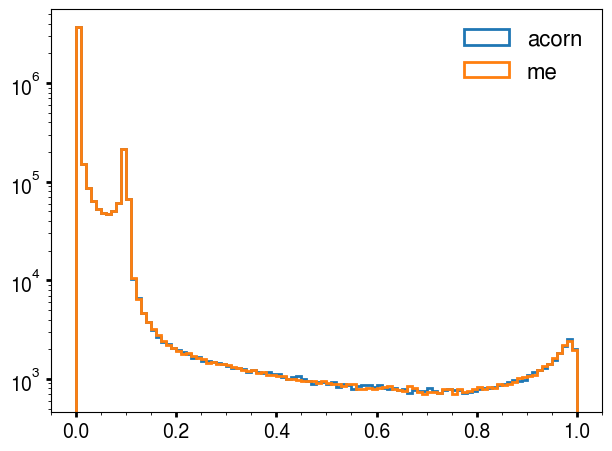

In [139]:
config = {
    "bins": 100,
    "range": (0, 1.0),
    "lw": 2,
    "log": True,
    "histtype": "step",
}
plt.hist(my_filter_output_data.edge_scores.cpu().numpy(), **config, label="acorn")
plt.hist(my_output.edge_scores.cpu().numpy(), **config, label="me")
# plt.hist(my_output_v1.edge_scores.cpu().numpy(), **config, label="me v1")
plt.legend()
# plt.xscale('log');

In [58]:
in_filter_data.edge_index.shape, in_filter_data.edge_index[:, 0]

(torch.Size([2, 4650368]), tensor([ 0, 75]))

In [64]:
out_filter_data = torch.load(f"{results_filtering_path}/{data_type}/event[\'{event_id:09d}\'].pyg", map_location="cpu")

In [71]:
edge_scores = out_filter_data.edge_scores
edge_index = out_filter_data.edge_index


In [75]:
edge_scores[:10], my_output.edge_scores[:10]

(tensor([9.2171e-03, 3.0585e-04, 1.8184e-04, 2.0271e-01, 1.9221e-04, 2.4652e-04,
         3.5209e-04, 5.0722e-04, 9.9393e-01, 3.3619e-03]),
 tensor([9.9832e-02, 9.8946e-02, 8.2635e-02, 1.3658e-03, 3.0646e-04, 1.9846e-04,
         3.6897e-01, 5.2263e-02, 1.1303e-03, 4.0195e-04]))

In [77]:
edge_index[:, edge_index[0] == 0], my_output.edge_index[:, my_output.edge_index[0] == 0]

(tensor([[    0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0],
         [   75,   147,   298,   993,  1065,  1136,   155,   221,   228,  1151,
          23391, 23458]]),
 tensor([[    0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0],
         [   75,   147,   155,   221,   228,   298,   993,  1065,  1136,  1151,
          23391, 23458]]))

## GNN

### Scores

In [109]:
out_gnn_data = torch.load(f"{results_gnn_path}/{data_type}/event[[\'{event_id:09d}\']].pyg", map_location="cpu")

In [120]:
gnn_score = out_gnn_data.edge_scores
edge_index = out_gnn_data.edge_index

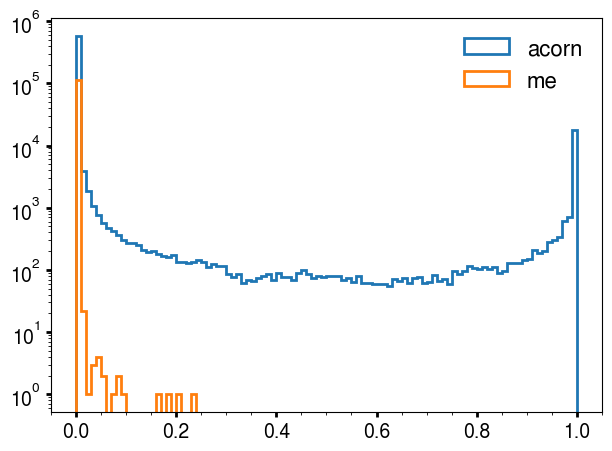

In [157]:
config = {
    "bins": 100,
    "range": (0, 1.0),
    "lw": 2,
    "log": True,
    "histtype": "step",
}
plt.hist(gnn_score.cpu().numpy(), **config, label="acorn")
plt.hist(my_output.gnn_scores.cpu().numpy(), **config, label="me")
plt.legend()

In [132]:
edge_index[:, edge_index[0] == 0], edge_index[:, edge_index[1] == 14497]

(tensor([[  0],
         [993]]),
 tensor([[    3,     6,     5],
         [14497, 14497, 14497]]))

In [133]:
my_output.edge_index[:, my_output.edge_index[1] == 14497]

tensor([[   19,   146,   162,   171],
        [14497, 14497, 14497, 14497]])

In [146]:
torch.sum(edge_index[0] > edge_index[1]), torch.sum(my_output.gnn_input_edges[0] > my_output.gnn_input_edges[1])

(tensor(0), tensor(100659))

In [159]:
gnn_score, my_output.gnn_scores

(tensor([1.7083e-03, 1.0000e+00, 2.9753e-05,  ..., 1.4914e-04, 4.5465e-04,
         1.5564e-03]),
 tensor([       nan, 2.5380e-05,        nan,  ...,        nan,        nan,
                nan]))

In [129]:
my_output.edge_index[:, :10]

tensor([[   0,  147,    0,    0,    0,    0,    0,    0,    0, 1151],
        [  75,    0,  155,  221,  228,  298,  993, 1065, 1136,    0]])

## Tracks

In [38]:
tracks_text = f"{results_track_path}/{data_type}_tracks/event[[\'{event_id:09d}\']].txt"

In [39]:
tracks_from_jay = [line.split() for line in open(tracks_text, "r").readlines()]

In [40]:
tracks_from_jay = [x for x in tracks_from_jay if len(x) > 2]

In [41]:
len(tracks_from_jay)

4914

In [42]:
my_list = [1, -1, 2, -1, 3, -1, 4]
count = my_list.count(-1)
print(count)

3
